# Sentiment Analysis EDA

This notebook explores the CantoNLU sentiment-analysis dataset for Milestone 2.

The goals are to verify:
- dataset sizes
- columns and labels
- class balance
- missing values
- duplicate examples
- overlap between train, validation, and test
- text-length distributions
- sample examples

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [15]:
DATA_DIR = Path("../data/sentiment")

train = pd.read_json(DATA_DIR / "train.jsonl", lines=True)
valid = pd.read_json(DATA_DIR / "valid.jsonl", lines=True)
test = pd.read_json(DATA_DIR / "test.jsonl", lines=True)

In [16]:
print("Train shape:", train.shape)
print("Validation shape:", valid.shape)
print("Test shape:", test.shape)

Train shape: (9999, 4)
Validation shape: (999, 4)
Test shape: (999, 4)


In [17]:
print("Train columns:", train.columns.tolist())

train.head()

Train columns: ['id', 'sentence', 'label', 'source']


,id,sentence,label,source
0,0,正宗大板燒 🐿🐿TOP開左都一段日子，餐廳都好幾層！今日就嚟試下千房(^^) 大板燒專門店🤤...,smile,openrice
1,1,"唔見得比其他酒家特別好食 一行7人到此酒家食晚飯, 7道海鮮 + 雞連炒飯 & 炒菜共10道...",ok,openrice
2,2,質素同價錢唔成正比 今日嚟到呢間牛肉麵店食晏，一個人食坐嘅位比較窄，但佢環境都好衛生同埋裝修...,cry,openrice
3,3,燒汁雞扒刈包好味 上星期和朋友去杏花邨睇波鞋啲時候，覺得肚餓，於是就落咗一層睇下有咩下午餐好...,smile,openrice
4,4,"上海妹子 下午茶 我地一聚埋就會好想搵個地方坐低飲啖茶食個飽, 妹子佢話想食小籠包,下一秒我...",ok,openrice


In [18]:
valid.head()

,id,sentence,label,source
0,0,不錯的小店 呢間小店做左都有幾年，平時唔覺好旺，但因為附近都冇咩bakery，得呢間，見佢門...,smile,openrice
1,1,"我係來拉低個分的。 等佢咪誤導人嘛。 7個同學, 考完試特地去刷餐好的。素聞隨行一位同學強推...",ok,openrice
2,2,薯條比漢堡好食嘅 仲於可以一試傳說中抵食又好味嘅漢堡。 佢漢堡嘅特色在於你可以自己揀想要嘅...,cry,openrice
3,3,CP 值高既CAFE 每日最大既難題就係諗晏就食咩好，同事話想去呢間咖啡店試新野，咁就一齊去...,smile,openrice
4,4,蒸飯點心 平時lunch多數買附近包點先生既蒸飯，見呢間新開又平少少，所以今日就行多少少路黎...,ok,openrice


In [19]:
test.head()

,id,sentence,label,source
0,0,用粥底嚟打邊爐 黃氏力牆其實我想係呢一度打邊爐好耐啦，今日終於有機會！我叫左兩個一模一樣嘅...,smile,openrice
1,1,食物ok 飲品唔得 見有新野 特登黎試下 星期六晚上8時黎到 都要略略等一等位 黎之前上網見...,ok,openrice
2,2,貴野亦都無好嘢 見新開張，又無人排隊，同女友兩個嚟試下，點知中伏😰........以為平嘢無...,cry,openrice
3,3,多款吸引佐酒小食 開業好像而達十年之居的居酒屋，朋友帶路下來嘗嘗。 整個餐牌都好吸引，幾...,smile,openrice
4,4,野食一般 蛋撻唔錯 🍴蛋撻 😃 呢間車氏我都係朋友帶我黎 我先第一次試 . 坦白講 野食一般...,ok,openrice


In [20]:
print("Train labels:")
print(train["label"].value_counts())

print("\nValidation labels:")
print(valid["label"].value_counts())

print("\nTest labels:")
print(test["label"].value_counts())

Train labels:
label
smile    3333
ok       3333
cry      3333
Name: count, dtype: int64

Validation labels:
label
smile    333
ok       333
cry      333
Name: count, dtype: int64

Test labels:
label
smile    333
ok       333
cry      333
Name: count, dtype: int64


In [21]:
print("Train missing values:")
print(train.isna().sum())

print("\nValidation missing values:")
print(valid.isna().sum())

print("\nTest missing values:")
print(test.isna().sum())

Train missing values:
id          0
sentence    0
label       0
source      0
dtype: int64

Validation missing values:
id          0
sentence    0
label       0
source      0
dtype: int64

Test missing values:
id          0
sentence    0
label       0
source      0
dtype: int64


In [22]:
print("Train duplicate rows:", train.duplicated().sum())
print("Validation duplicate rows:", valid.duplicated().sum())
print("Test duplicate rows:", test.duplicated().sum())

Train duplicate rows: 0
Validation duplicate rows: 0
Test duplicate rows: 0


In [23]:
print("Train duplicate sentences:", train["sentence"].duplicated().sum())
print("Validation duplicate sentences:", valid["sentence"].duplicated().sum())
print("Test duplicate sentences:", test["sentence"].duplicated().sum())

Train duplicate sentences: 0
Validation duplicate sentences: 0
Test duplicate sentences: 0


In [24]:
train_sentences = set(train["sentence"])
valid_sentences = set(valid["sentence"])
test_sentences = set(test["sentence"])

print("Train / Validation overlap:", len(train_sentences & valid_sentences))
print("Train / Test overlap:", len(train_sentences & test_sentences))
print("Validation / Test overlap:", len(valid_sentences & test_sentences))

Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0


In [25]:
for df in [train, valid, test]:
    df["text_length"] = df["sentence"].str.len()

print("Train text-length summary:")
print(train["text_length"].describe())

print("\nValidation text-length summary:")
print(valid["text_length"].describe())

print("\nTest text-length summary:")
print(test["text_length"].describe())

Train text-length summary:
count    9999.000000
mean      343.853285
std       187.949781
min        40.000000
25%       236.000000
50%       288.000000
75%       397.000000
max      4720.000000
Name: text_length, dtype: float64

Validation text-length summary:
count     999.000000
mean      340.306306
std       165.935142
min        47.000000
25%       234.500000
50%       285.000000
75%       393.500000
max      1290.000000
Name: text_length, dtype: float64

Test text-length summary:
count     999.000000
mean      341.829830
std       178.350376
min        82.000000
25%       235.000000
50%       289.000000
75%       390.000000
max      1881.000000
Name: text_length, dtype: float64


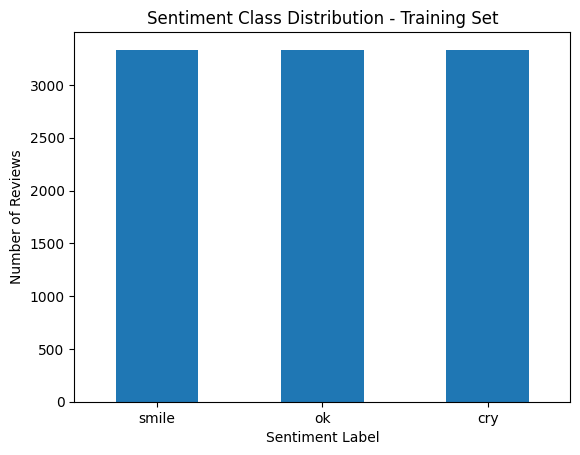

In [26]:
train["label"].value_counts().plot(kind="bar")

plt.title("Sentiment Class Distribution - Training Set")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

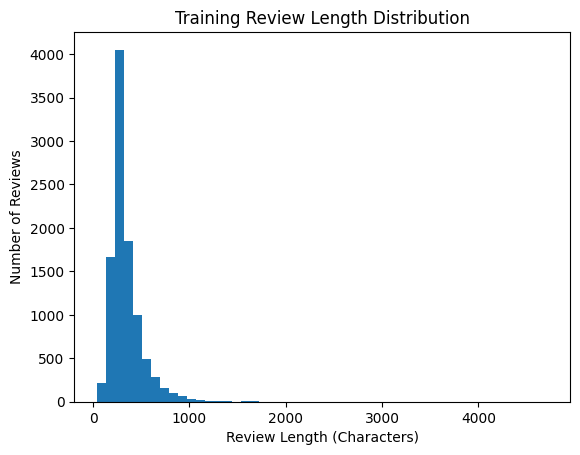

In [27]:
train["text_length"].plot(kind="hist", bins=50)

plt.title("Training Review Length Distribution")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.show()

In [28]:
train.nlargest(10, "text_length")[["sentence", "label", "text_length"]]

,sentence,label,text_length
3709,無限出錯還要我原諒您地拾玖幾次嗎？ 職員態度傲慢輕佻，無限輪迴地出錯，抱著不忍輸、不忍錯的信...,ok,4720
2724,藝力美食之旅 80日可以環遊世界，咁60日可以做啲咩呢？早前晌「富豪機場酒店」嘅「藝廊咖啡室...,smile,3984
8963,通常差既我都唔寫，但呢間唔寫唔舒服 上網見某大平台經常賣廣告講到好正好好玩， 又有啲似日本某...,cry,3240
2787,歡樂到雲 補祝老婆生日，唔單止入嚟迪士尼玩番日，仲食番餐好嘅。之前嚟都喺晌樂園裡面嘅餐廳度食...,smile,2980
9551,良莠不齊~囍慶~ 又有新酒樓開啦~ 有鑑於之前既不愉快經驗 所以今次揀間集團式既食啦~ 反正...,cry,2189
2424,食海鮮唔一定要係外國 蟹先生比到你要既野!!!!! 當你跟你朋友 都想吃海鮮時 腦中反射出的...,smile,2123
5869,MacBuffet 咪誤會以為麥記搞起自助餐嚟 ，此麥跟彼麥不同。今次跟老婆嘅朋友行山，地域...,ok,2083
189,實在離譜 今個中秋，難得大部分屋企人都放假，梗係要去玩下。行山呢類有益身心嘅活動，當然一呼百...,smile,2012
713,確真「小家」 姨媽們每次回港都總會有新潮點o既資訊，消息絕對比XO仔靈通得多。上個月尾走咗轉...,cry,1977
6778,午餐在羅馬 因工關係，去咗香港基督少年軍個馬灣臻訓中心做訓練 ，主要都係啲攀攀爬爬嘅嘢，體力...,ok,1918


In [29]:
for label in ["smile", "ok", "cry"]:
    print(f"\nExamples for label: {label}")
    display(
        train[train["label"] == label][
            ["sentence", "text_length"]
        ].head(3)
    )


Examples for label: smile


,sentence,text_length
0,正宗大板燒 🐿🐿TOP開左都一段日子，餐廳都好幾層！今日就嚟試下千房(^^) 大板燒專門店🤤...,311
3,燒汁雞扒刈包好味 上星期和朋友去杏花邨睇波鞋啲時候，覺得肚餓，於是就落咗一層睇下有咩下午餐好...,242
6,白雪雪烏冬☁️☁️ 朋友今日突然想食燒牛肉 就帶佢黎呢間吉列牛專門店食啦 我都五系第一次黎食...,285



Examples for label: ok


,sentence,text_length
1,"唔見得比其他酒家特別好食 一行7人到此酒家食晚飯, 7道海鮮 + 雞連炒飯 & 炒菜共10道...",92
4,"上海妹子 下午茶 我地一聚埋就會好想搵個地方坐低飲啖茶食個飽, 妹子佢話想食小籠包,下一秒我...",307
7,"挑戰麻辣五小的一天 瞓到""黃朝八晏""，諗唔到食乜只係想食辣，咁啱要去淘大就先食個三哥做lat...",260



Examples for label: cry


,sentence,text_length
2,質素同價錢唔成正比 今日嚟到呢間牛肉麵店食晏，一個人食坐嘅位比較窄，但佢環境都好衛生同埋裝修...,284
5,冷氣聲大到影響心情 呢度食物sell健康 無雞粉 味精 激素 好似幾值得食 所以就叫左個慢煮...,249
8,得個平字.... 所有野係得雞扒飯最好食(士油)... set lunch好唔得.... 環...,75


## Initial Findings

- The training set contains 9,999 examples, while the validation and test sets each contain 999 examples.
- The dataset contains four fields: `id`, `sentence`, `label`, and `source`.
- The sentiment labels are `smile`, `ok`, and `cry`.
- All three splits are perfectly balanced across the three sentiment classes.
- No missing values were found in any split.
- No duplicate rows or duplicate review texts were found within the splits.
- No review-text overlap was found between the training, validation, and test sets.
- Median review length is approximately 285–289 characters across the three splits.
- The review-length distribution is right-skewed, with most reviews under 1,000 characters and a small number of much longer examples.
- The longest training review contains 4,720 characters. Manual inspection suggests that the longest examples are legitimate reviews rather than obviously malformed data.
- Sample reviews contain informal Cantonese, code-switching, English words, and emoji.
- Overall, the sentiment dataset appears clean and suitable for baseline modelling without major cleaning.